# FDP upper bound in outlier detection

## 1. Setup

We begin by importing some standard libraries that will be useful for this example.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import random
from scipy.stats import multivariate_normal

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from ecdf_upper_bound import uniform_ecdf_upper_bound, sample_cpvals, uniform_FDP_upper_bound

class ToyModel:
    def __init__(self, p, amplitude, random_state=2020):
        #np.random.seed(random_state)
        self.p = p
        self.a = amplitude
        self.Z = np.random.uniform(low=-3, high=3, size=(p,p))

    def _sample_clean(self, n):
        p = self.p
        X = np.random.randn(n, p)
        cluster_idx = np.random.choice(self.Z.shape[0], n, replace=True)
        X = X + self.Z[cluster_idx,]
        return X

    def _sample_outlier(self, n):
        p = self.p
        X = (np.sqrt(self.a)+ 1) * np.random.randn(n, p)
        cluster_idx = np.random.choice(self.Z.shape[0], n, replace=True)
        X = X + self.Z[cluster_idx,]
        return X

    def sample(self, n, purity=1, random_state=2020):
        p = self.p
        np.random.seed(random_state)
        purity = np.clip(purity, 0, 1)
        n_clean = np.round(n * purity).astype(int)
        n_outlier = n - n_clean
        X_clean = self._sample_clean(n_clean)
        is_outlier = np.zeros((n,))
        if n_outlier > 0:
            X_outlier = self._sample_outlier(n_outlier)
            idx_clean, idx_outlier = train_test_split(np.arange(n), test_size=n_outlier)
            X = np.zeros((n,p))
            X[idx_clean,:] = X_clean
            X[idx_outlier,:] = X_outlier
            is_outlier[idx_outlier] = 1
        else:
            X = X_clean
        return X, is_outlier.astype(int)




Now we import our custom library for this project, included in this repository.

In [2]:
import os
import sys
sys.path.append('../')



## 2. Data generation

We will generate 50-dimensional data from the same toy model as in the paper (and as in Notebook 1).

In [3]:
random_state = np.random.randint(1, 20001)
print(random_state)
p = 50        # Number of features
a = 0.1  # Signal amplitude

model = ToyModel(p, a, random_state=np.random.randint(1000, 2001))

n = 1000     # Number of observations
purity = 0.8  # Proportion of inliers

X, is_outlier = model.sample(n, purity=purity)

print("Number of inliers: {}.".format(np.sum(is_outlier==0)))
print("Number of outliers: {}.".format(np.sum(is_outlier==1)))

6721
Number of inliers: 800.
Number of outliers: 200.


We will also generate a separate clean data set (no outliers) for training and calibration.

In [4]:
X_clean, _ = model.sample(n, purity=1)

## 3. Training an outlier detection black-box algorithm

First, we split the clean data set into training and calibration subsets. Then, we fit a one-class classifier on the training data.

In [5]:
# Split data into training and calibration subsets
X_train, X_calib = train_test_split(X_clean, test_size=0.5, random_state=random_state) 

# Choose a one-class classifier algorithm
method_oneclass = "SVM"

# Initialize the one-class classifier
contamination = 0.001
contamination = min(max(contamination,0.004),0.1)
if method_oneclass == "SVM":
    classifier = svm.OneClassSVM(nu=contamination, kernel="rbf", gamma=0.1)
if method_oneclass == "IForest":
    classifier = IsolationForest(random_state=random_state, contamination=contamination)
if method_oneclass == "Neighbors":
    classifier = LocalOutlierFactor(novelty=True, contamination=contamination)
    
# Fit the black-box one-class classifier
classifier.fit(X_train)

OneClassSVM(gamma=0.1, nu=0.004)

## 4. Compute a calibration curve

Apply the one-class classifier to compute scores for the hold-out clean calibration data points.

In [6]:
# Compute scores on clean calibration data
calib_score = classifier.score_samples(X_calib)
test_score = classifier.score_samples(X)
n = len(calib_score)
m = len(test_score)

Then, compute the simultaneous upper confidence bound for the FDP, with $\delta=0.1$.

In [7]:
def compute_T(pvals, l = 0.5):
    m = len(pvals)
    vec = np.arange(1,m+1)
    numerator = np.cumsum(pvals<l)-l*vec
    delta = np.sqrt(vec*l*(1-l))
    return np.max(numerator/delta)

def fdp_upper_bound_outlier_detection(pvals, n,m, N = 1000, delta = 0.1, lamda = 0.5, method = 'MC-HC', boost_method = [True, True]):
    if boost_method[1]:
        N = 1000
        all_samples = np.zeros((N,m))
        for t in range(N):
            pvals_tem = sample_cpvals(n,m)
            all_samples[t] = pvals_tem

        r = m
        upper_simulation = uniform_ecdf_upper_bound(n = n, m = r, N = N, delta = 0.1, method = 'MC-HC')
        mhat = r
        for r in range(m, 0, -1):
            
            upper_simulation = uniform_ecdf_upper_bound(n = n, m = r, N = N, delta = 0.1, method = 'MC-HC')
            if all([sum(pvals >= pval) - 1 >= r - upper_simulation(pval) * r for pval in pvals]):
                mhat = r
                break   
    else:
        mhat = m
    print('upper bound on m', mhat)
    if boost_method[0]:
        upper_simulation = uniform_FDP_upper_bound(pvals, n = n, m = mhat, delta = delta/2, method = method, boost = True)
    else:
        upper_simulation = uniform_FDP_upper_bound(pvals, n = n, m = mhat, delta = delta/2, method = method, boost = False)
    return upper_simulation

KeyboardInterrupt: 

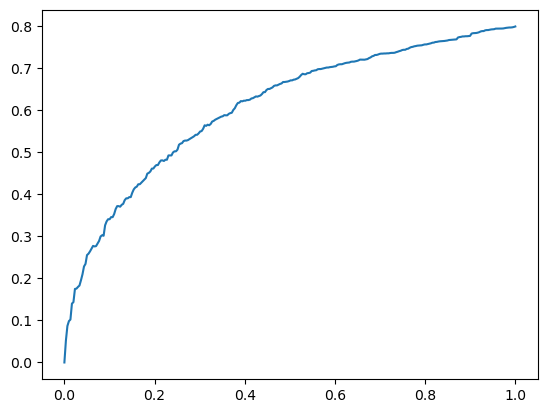

In [8]:
grid= np.linspace(0,1,300)

pvals = np.zeros(m)
for idx in range(m):
        pvals[idx] = (np.random.rand(1)* (1+np.sum( calib_score == test_score[idx])) + np.sum( calib_score < test_score[idx]))/(n+1)
def FDP(alpha, pvals, truth):
    R = sum(pvals <= alpha)
    FR = R - sum(truth[pvals<=alpha])
    return FR/np.maximum(R,1)
FDP_true = np.zeros(grid.size)
for _ in range(grid.size):
      FDP_true[_] = FDP(grid[_], pvals, is_outlier)

plt.plot(grid, FDP_true, label='True FDP')
plt.plot(grid, fdp_upper_bound_outlier_detection(pvals, n, m)(grid), label='Simulation correction')
plt.xlabel('alpha')
plt.ylabel('Values')
plt.title('FDP upper bound with both boost methods')
plt.legend()

plt.xlim(0, 0.2)

plt.show()

upper bound on m 1000


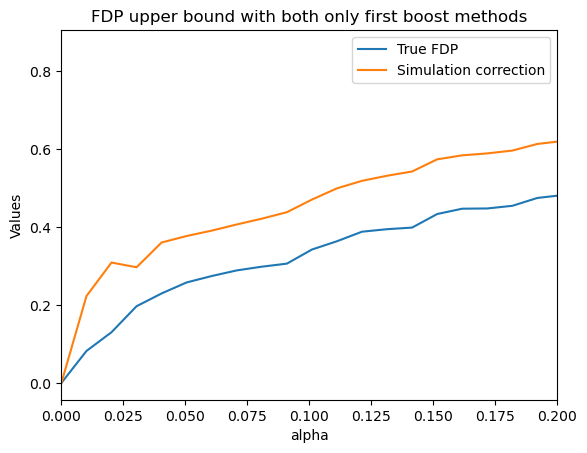

In [ ]:
grid= np.linspace(0,1,100)

pvals = np.zeros(m)
for idx in range(m):
        pvals[idx] = (np.random.rand(1)* (1+np.sum( calib_score == test_score[idx])) + np.sum( calib_score < test_score[idx]))/(n+1)
def FDP(alpha, pvals, truth):
    R = sum(pvals <= alpha)
    FR = R - sum(truth[pvals<=alpha])
    return FR/np.maximum(R,1)
FDP_true = np.zeros(grid.size)
for _ in range(grid.size):
      FDP_true[_] = FDP(grid[_], pvals, is_outlier)

plt.plot(grid, FDP_true, label='True FDP')
plt.plot(grid, fdp_upper_bound_outlier_detection(pvals, n, m, boost_method = [True, False])(grid), label='Simulation correction')
plt.xlabel('alpha')
plt.ylabel('Values')
plt.title('FDP upper bound with both only first boost methods')
plt.legend()

plt.xlim(0, 0.2)

plt.show()

upper bound on m 853


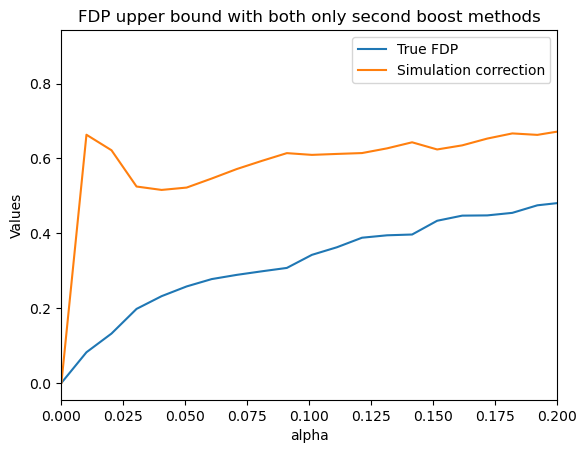

In [ ]:
grid= np.linspace(0,1,100)

pvals = np.zeros(m)
for idx in range(m):
        pvals[idx] = (np.random.rand(1)* (1+np.sum( calib_score == test_score[idx])) + np.sum( calib_score < test_score[idx]))/(n+1)
def FDP(alpha, pvals, truth):
    R = sum(pvals <= alpha)
    FR = R - sum(truth[pvals<=alpha])
    return FR/np.maximum(R,1)
FDP_true = np.zeros(grid.size)
for _ in range(grid.size):
      FDP_true[_] = FDP(grid[_], pvals, is_outlier)

plt.plot(grid, FDP_true, label='True FDP')
plt.plot(grid, fdp_upper_bound_outlier_detection(pvals, n, m, method = 'KS', boost_method = [False, True])(grid), label='Simulation correction')
plt.xlabel('alpha')
plt.ylabel('Values')
plt.title('FDP upper bound with both only second boost methods')
plt.legend()

plt.xlim(0, 0.2)

plt.show()

upper bound on m 1000


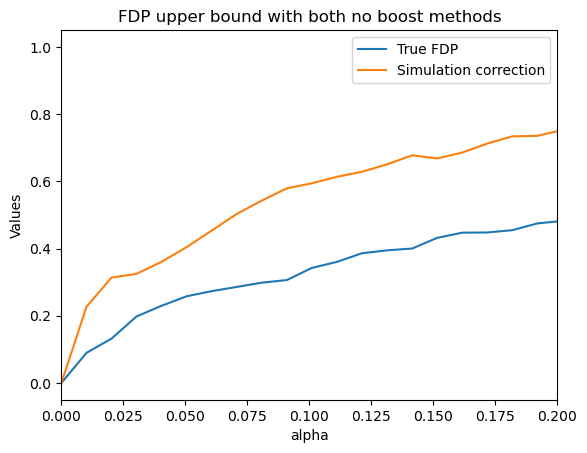

In [ ]:
grid= np.linspace(0,1,100)

pvals = np.zeros(m)
for idx in range(m):
        pvals[idx] = (np.random.rand(1)* (1+np.sum( calib_score == test_score[idx])) + np.sum( calib_score < test_score[idx]))/(n+1)
def FDP(alpha, pvals, truth):
    R = sum(pvals <= alpha)
    FR = R - sum(truth[pvals<=alpha])
    return FR/np.maximum(R,1)
FDP_true = np.zeros(grid.size)
for _ in range(grid.size):
      FDP_true[_] = FDP(grid[_], pvals, is_outlier)

plt.plot(grid, FDP_true, label='True FDP')
plt.plot(grid, fdp_upper_bound_outlier_detection(pvals, n, m, boost_method = [False, False])(grid), label='Simulation correction')
plt.xlabel('alpha')
plt.ylabel('Values')
plt.title('FDP upper bound with both no boost methods')
plt.legend()

plt.xlim(0, 0.2)

plt.show()

## Repeat experiments


In [9]:
def single_experiment(random_state, n = 1000, purity = 0.9, grid = np.linspace(0,1, 200), method = 'MC-HC', signal_strength = 1, boost_method = [False, False]):
    p = 50        # Number of features
    a = signal_strength    # Signal amplitude

    model = ToyModel(p, a, random_state=np.random.randint(1000, 2001))
    
    X, is_outlier = model.sample(n, purity=purity)

    X_clean, _ = model.sample(n, purity=1)

    # Split data into training and calibration subsets
    X_train, X_calib = train_test_split(X_clean, test_size=0.5, random_state=random_state) 

    # Choose a one-class classifier algorithm
    method_oneclass = "SVM"

    # Initialize the one-class classifier
    contamination = 0.001
    contamination = min(max(contamination,0.004),0.1)
    if method_oneclass == "SVM":
        classifier = svm.OneClassSVM(nu=contamination, kernel="rbf", gamma=0.1)
    if method_oneclass == "IForest":
        classifier = IsolationForest(random_state=random_state, contamination=contamination)
    if method_oneclass == "Neighbors":
        classifier = LocalOutlierFactor(novelty=True, contamination=contamination)
        
    # Fit the black-box one-class classifier
    classifier.fit(X_train)

    # Compute scores on clean calibration data
    calib_score = classifier.score_samples(X_calib)
    test_score = classifier.score_samples(X)
    n = len(calib_score)
    m = len(test_score)

    pvals = np.zeros(m)
    for idx in range(m):
            pvals[idx] = (np.random.rand(1)* (1+np.sum( calib_score == test_score[idx])) + np.sum( calib_score < test_score[idx]))/(n+1)
    def FDP(alpha, pvals, truth):
        R = sum(pvals <= alpha)
        FR = R - sum(truth[pvals<=alpha])
        return FR/np.maximum(R,1)
    FDP_true = np.zeros(grid.size)
    for _ in range(grid.size):
        FDP_true[_] = FDP(grid[_], pvals, is_outlier)
    return FDP_true, fdp_upper_bound_outlier_detection(pvals, n, m, method = method, boost_method = boost_method)(grid)

upper bound on m 1000
upper bound on m 906
upper bound on m 906
upper bound on m 1000
upper bound on m 906
upper bound on m 906
upper bound on m 1000
upper bound on m 906
upper bound on m 906
upper bound on m 1000
upper bound on m 903
upper bound on m 903
upper bound on m 1000
upper bound on m 903
upper bound on m 903
upper bound on m 1000
upper bound on m 903
upper bound on m 903
upper bound on m 1000
upper bound on m 903
upper bound on m 903
upper bound on m 1000
upper bound on m 903
upper bound on m 903
upper bound on m 1000
upper bound on m 903
upper bound on m 903


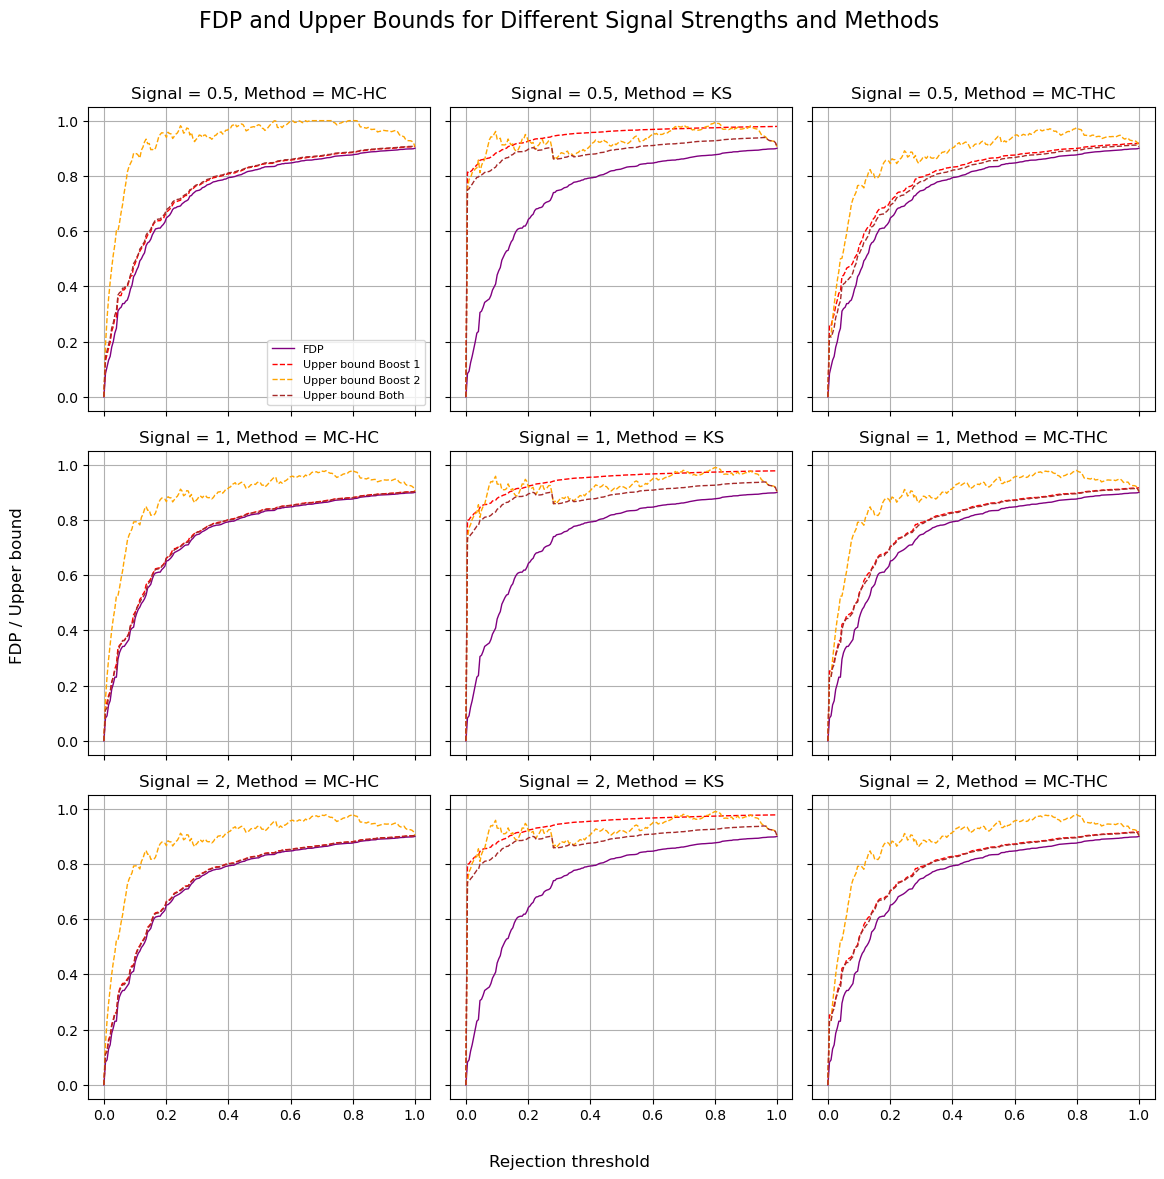

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

grid = np.linspace(0, 1, 200)
signal_strengths = [0.5,1,2]
methods = ['MC-HC', 'KS', 'MC-THC']
purity = 0.9

# Storage dict for saving all results
results = {
    "grid": grid,
    "signal_strengths": signal_strengths,
    "methods": methods,
    "purity": purity,
    "fdp_both": {},
    "fdp_upper_boost1": {},
    "fdp_upper_boost2": {},
    "fdp_upper_both": {}
}

fig, axes = plt.subplots(3, 3, figsize=(12, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, signal_strength in enumerate(signal_strengths):
    for j, method in enumerate(methods):
        
        fdp_boost1, fdp_upper_boost1 = single_experiment(
            42, purity=purity, signal_strength=signal_strength, grid = grid,
            method=method, boost_method=[True, False]
        )
        fdp_boost2, fdp_upper_boost2 = single_experiment(
            42, purity=purity, signal_strength=signal_strength, grid = grid,
            method=method, boost_method=[False, True]
        )
        fdp_both, fdp_upper_both = single_experiment(
            42, purity=purity, signal_strength=signal_strength, grid = grid,
            method=method, boost_method=[True, True]
        )

        # Save in dict
        key = (signal_strength, method)
        results["fdp_both"][key] = fdp_both
        results["fdp_upper_boost1"][key] = fdp_upper_boost1
        results["fdp_upper_boost2"][key] = fdp_upper_boost2
        results["fdp_upper_both"][key] = fdp_upper_both

        # Plot
        ax = axes[i * len(methods) + j]

        ax.plot(grid, fdp_both, label='FDP', color='purple', linewidth=1)
        ax.plot(grid, fdp_upper_boost1, label='Upper bound Boost 1', linestyle='--', color='red', linewidth=1)
        ax.plot(grid, fdp_upper_boost2, label='Upper bound Boost 2', linestyle='--', color='orange', linewidth=1)
        ax.plot(grid, fdp_upper_both, label='Upper bound Both', linestyle='--', color='brown', linewidth=1)

        ax.set_title(f'Signal = {signal_strength}, Method = {method}')
        ax.grid(True)

        if i == 0 and j == 0:
            ax.legend(fontsize=8)

# Common labels
fig.text(0.5, 0.02, 'Rejection threshold', ha='center', va='center', fontsize=12)
fig.text(0.04, 0.5, 'FDP / Upper bound', ha='center', va='center', rotation='vertical', fontsize=12)
fig.suptitle('FDP and Upper Bounds for Different Signal Strengths and Methods', fontsize=16)

plt.tight_layout(rect=[0.06, 0.04, 1, 0.96])

# Save plot
#plt.savefig("figure/figure4_fixed_purity.pdf", format="pdf")
plt.show()

# SAVE THE NUMPY ARCHIVE
np.savez("experiment_result/FDP_outlier_fixed_purity_0.5_1_2.npz", **results)


In [ ]:
methods[0], methods[1] = methods[1], methods[0]

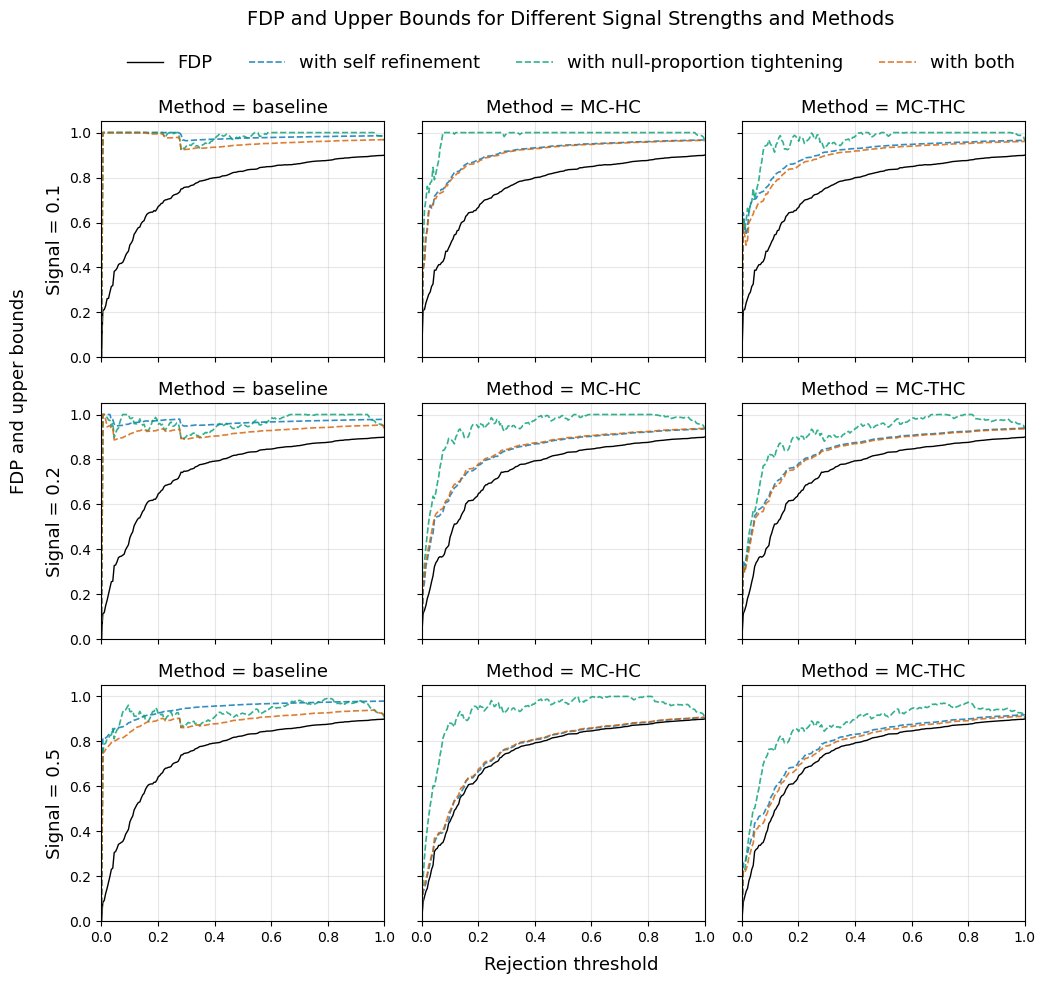

In [6]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("experiment_result/FDP_outlier_fixed_purity.npz", allow_pickle=True)

grid = data["grid"]
signal_strengths = data["signal_strengths"]
methods = data["methods"]          # keep original, so keys match the dicts
method_to_plot = [methods[1], methods[0], methods[2]]   # column order

fdp_both = data["fdp_both"].item()
fdp_upper_boost1 = data["fdp_upper_boost1"].item()
fdp_upper_boost2 = data["fdp_upper_boost2"].item()
fdp_upper_both = data["fdp_upper_both"].item()

# Create subplot layout
fig, axes = plt.subplots(len(signal_strengths), len(methods),
                         figsize=(12, 10), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

legend_handles, legend_labels = None, None

for i, signal_strength in enumerate(signal_strengths):
    for j, method in enumerate(method_to_plot):

        key = (signal_strength, method)
        ax = axes[i, j]

        # FDP and bounds
        line_fdp, = ax.plot(
            grid, fdp_both[key],
            label='FDP',
            color='black', linewidth=1
        )
        line_boost1, = ax.plot(
            grid, fdp_upper_boost1[key],
            '--', color='#0072B2', linewidth=1.2, alpha=0.8,
            label='with self refinement'
        )
        line_boost2, = ax.plot(
            grid, fdp_upper_boost2[key],
            '--', color='#009E73', linewidth=1.2, alpha=0.8,
            label='with null-proportion tightening'
        )
        line_both, = ax.plot(
            grid, fdp_upper_both[key],
            '--', color='#D55E00', linewidth=1.2, alpha=0.8,
            label='with both'
        )

        # display name: rename KS -> baseline ONLY in title
        display_method = "baseline" if method == "KS" else method
        ax.set_title(f"Method = {display_method}", fontsize=13)

        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)

        if i == 0 and legend_handles is None:
            legend_handles = [line_fdp, line_boost1, line_boost2, line_both]
            legend_labels = [h.get_label() for h in legend_handles]

        if j == 0:
            ax.set_ylabel(f'Signal = {signal_strength}', fontsize=13)


# Shared axis labels
fig.text(0.5, 0.02, 'Rejection threshold', ha='center', fontsize=13)
fig.text(0.04, 0.5, 'FDP and upper bounds', ha='center',
         rotation='vertical', fontsize=13)

fig.suptitle('FDP and Upper Bounds for Different Signal Strengths and Methods', fontsize=14)

fig.legend(
    legend_handles, legend_labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=13,
    borderpad=0.3,
    bbox_to_anchor=(0.5, 0.95)
)

plt.tight_layout(rect=[0.05, 0.03, 0.9, 0.94])

plt.savefig("figure/fixed_purity.pdf", format="pdf", dpi=300)
plt.show()


upper bound on m 1000
upper bound on m 755
upper bound on m 755
upper bound on m 1000
upper bound on m 755
upper bound on m 755
upper bound on m 1000
upper bound on m 755
upper bound on m 755
upper bound on m 1000
upper bound on m 830
upper bound on m 834
upper bound on m 1000
upper bound on m 834
upper bound on m 834
upper bound on m 1000
upper bound on m 830
upper bound on m 834
upper bound on m 1000
upper bound on m 936
upper bound on m 936
upper bound on m 1000
upper bound on m 936
upper bound on m 936
upper bound on m 1000
upper bound on m 936
upper bound on m 936


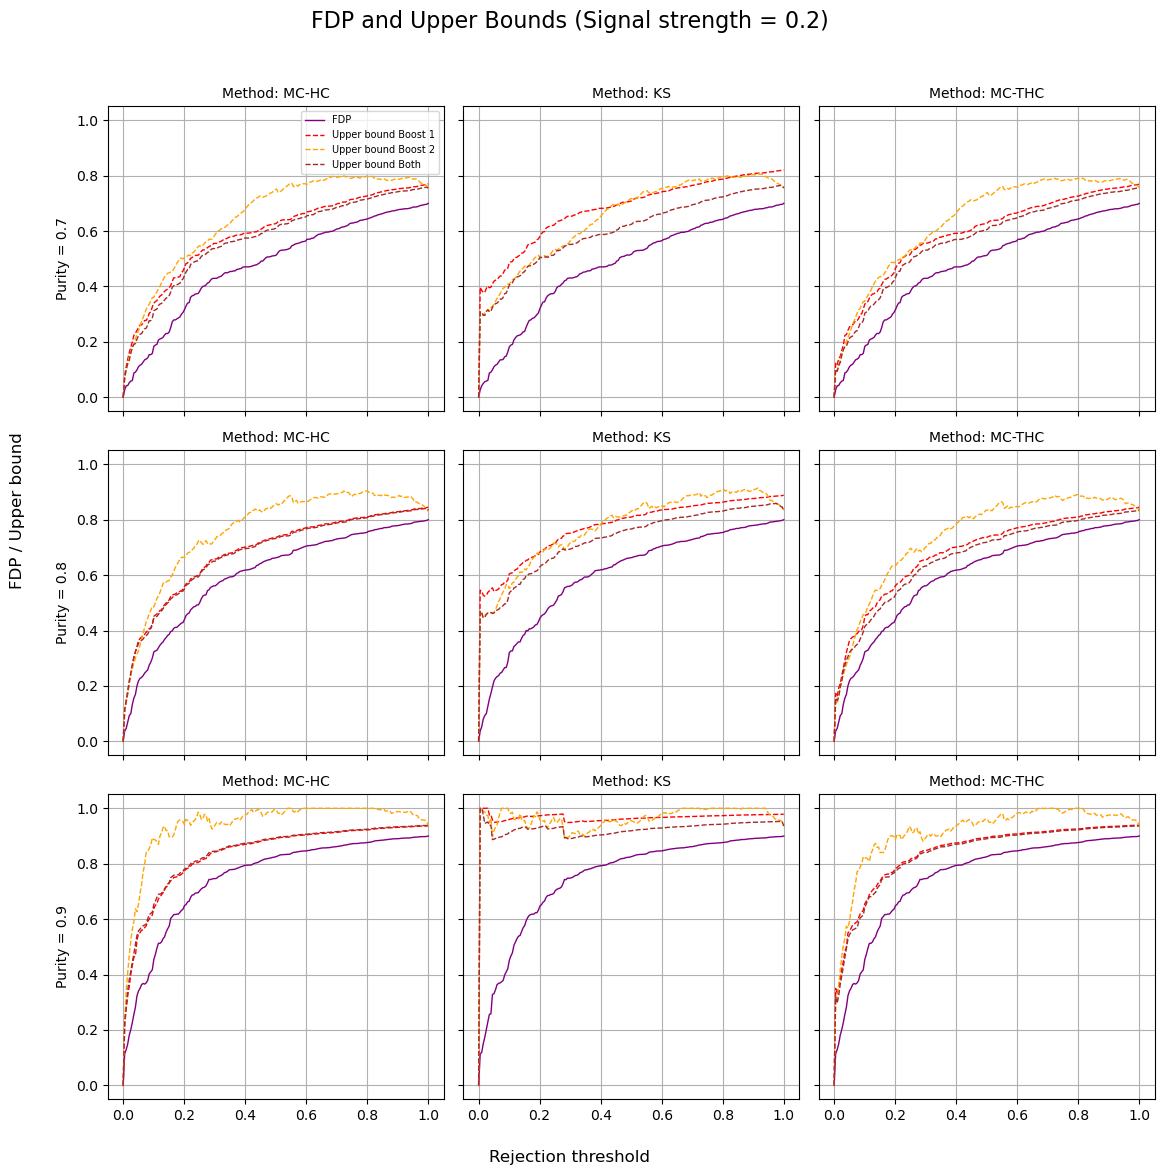

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Grid of rejection thresholds
grid = np.linspace(0, 1, 200)

# Fixed signal strength
signal_strength = 0.2

# Varying purity values for rows
purities = [0.7, 0.8, 0.9]

# Methods for columns
methods = ['MC-HC', 'KS', 'MC-THC']

# -----------------------------
# Storage dictionary for saving
# -----------------------------
results = {
    "grid": grid,
    "signal_strength": signal_strength,
    "purities": purities,
    "methods": methods,

    "fdp_boost1": {},
    "fdp_boost2": {},
    "fdp_both": {},

    "fdp_upper_boost1": {},
    "fdp_upper_boost2": {},
    "fdp_upper_both": {},
}

# Create subplots
fig, axes = plt.subplots(len(purities), len(methods), figsize=(12, 12),
                         sharex=True, sharey=True)
axes = np.atleast_2d(axes)

for i, purity in enumerate(purities):
    for j, method in enumerate(methods):
        
        # Run experiments
        fdp_boost1, ub_boost1 = single_experiment(
            42, purity=purity, signal_strength=signal_strength,
            method=method, boost_method=[True, False]
        )
        fdp_boost2, ub_boost2 = single_experiment(
            42, purity=purity, signal_strength=signal_strength,
            method=method, boost_method=[False, True]
        )
        fdp_both, ub_both = single_experiment(
            42, purity=purity, signal_strength=signal_strength,
            method=method, boost_method=[True, True]
        )

        # Save results
        key = (purity, method)
        results["fdp_boost1"][key] = fdp_boost1
        results["fdp_boost2"][key] = fdp_boost2
        results["fdp_both"][key] = fdp_both
        results["fdp_upper_boost1"][key] = ub_boost1
        results["fdp_upper_boost2"][key] = ub_boost2
        results["fdp_upper_both"][key] = ub_both

        # Plot (your code)
        ax = axes[i, j]
        ax.plot(grid, fdp_both, label='FDP', color='purple', linewidth=1)
        ax.plot(grid, ub_boost1, '--', color='red', linewidth=1, label='Upper bound Boost 1')
        ax.plot(grid, ub_boost2, '--', color='orange', linewidth=1, label='Upper bound Boost 2')
        ax.plot(grid, ub_both, '--', color='brown', linewidth=1, label='Upper bound Both')

        ax.set_title(f'Method: {method}', fontsize=10)
        ax.grid(True)

        if j == 0:
            ax.set_ylabel(f'Purity = {purity}', fontsize=10)

        if i == 0 and j == 0:
            ax.legend(fontsize=7)

# Labels
fig.text(0.5, 0.02, 'Rejection threshold', ha='center', fontsize=12)
fig.text(0.04, 0.5, 'FDP / Upper bound', ha='center', rotation='vertical', fontsize=12)
fig.suptitle(f'FDP and Upper Bounds (Signal strength = {signal_strength})', fontsize=16)

plt.tight_layout(rect=[0.06, 0.04, 1, 0.96])

# plt.show()

# SAVE THE NUMPY ARCHIVE
np.savez("experiment_result/FDP_outlier_fixed_signal_strength.npz", **results)


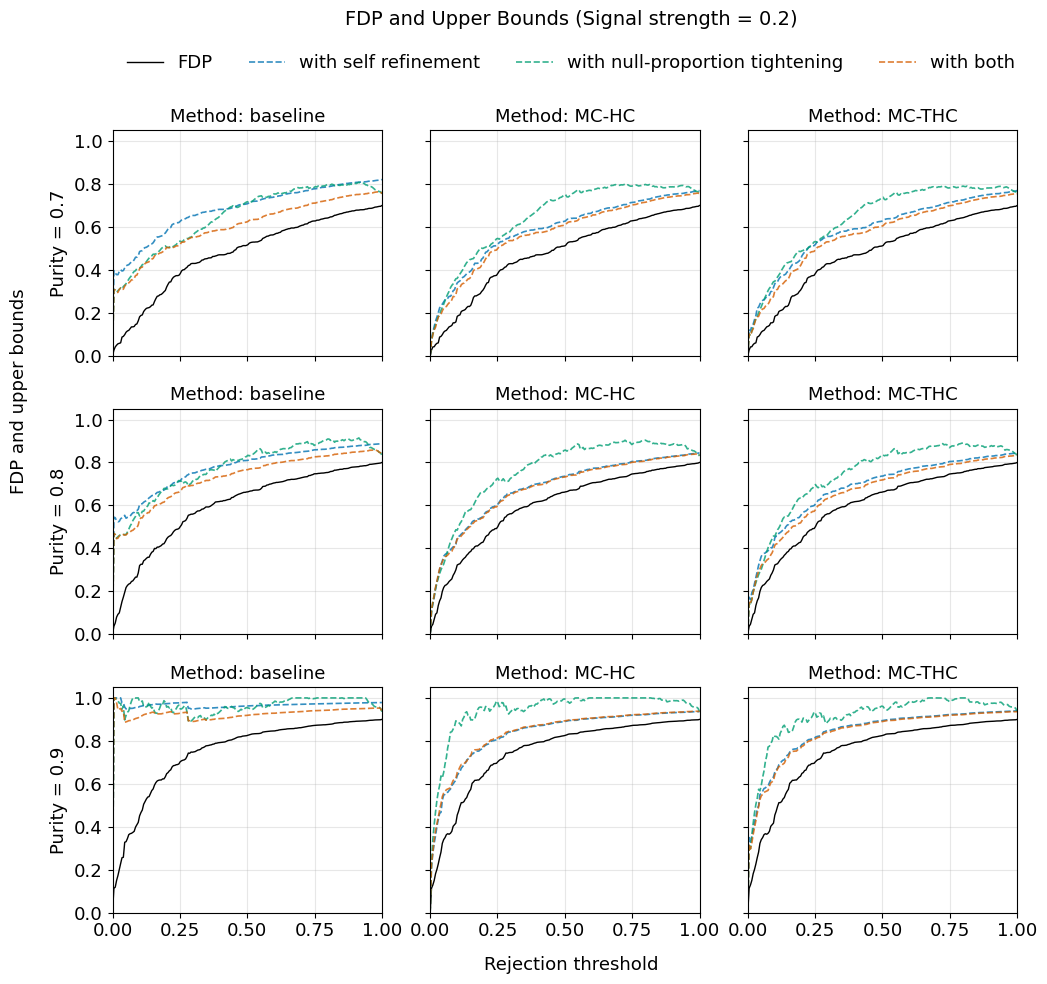

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load saved results
data = np.load("experiment_result/FDP_outlier_fixed_signal_strength.npz",
               allow_pickle=True)

grid = data["grid"]
signal_strength = float(data["signal_strength"])
purities = data["purities"]

methods = data["methods"]            # keep original for keys
method_to_plot = [methods[1], methods[0], methods[2]]   # column order

# Display names (rename KS → baseline only when printing)
def display_name(m):
    return "baseline" if m == "KS" else m

fdp_boost1 = data["fdp_boost1"].item()
fdp_boost2 = data["fdp_boost2"].item()
fdp_both = data["fdp_both"].item()
fdp_upper_boost1 = data["fdp_upper_boost1"].item()
fdp_upper_boost2 = data["fdp_upper_boost2"].item()
fdp_upper_both = data["fdp_upper_both"].item()



for i, purity in enumerate(purities):
    for j, method in enumerate(method_to_plot):
        key = (purity, method)
        ax = axes[i, j]

        # FDP and 3 upper bounds
        line_fdp, = ax.plot(
            grid, fdp_both[key], color='black', linewidth=1, label='FDP'
        )
        line_boost1, = ax.plot(
            grid, fdp_upper_boost1[key],
            '--', color='#0072B2', linewidth=1.2, alpha=0.8,
            label='with self refinement'
        )
        line_boost2, = ax.plot(
            grid, fdp_upper_boost2[key],
            '--', color='#009E73', linewidth=1.2, alpha=0.8,
            label='with null-proportion tightening'
        )
        line_both, = ax.plot(
            grid, fdp_upper_both[key],
            '--', color='#D55E00', linewidth=1.2, alpha=0.8,
            label='with both'
        )

        # Display name (KS → baseline)
        ax.set_title(f"Method: {display_name(method)}", fontsize=13)

        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)

        if i == 0 and legend_handles is None:
            legend_handles = [line_fdp, line_boost1, line_boost2, line_both]
            legend_labels = [h.get_label() for h in legend_handles]

        if j == 0:
            ax.set_ylabel(f'Purity = {purity}', fontsize=13)

# Labels and title
fig.text(0.5, 0.02, 'Rejection threshold', ha='center', fontsize=13)
fig.text(0.04, 0.5, 'FDP and upper bounds', ha='center', rotation='vertical',
         fontsize=13)

fig.suptitle(f'FDP and Upper Bounds (Signal strength = {signal_strength})',
             fontsize=14)

# Top legend
fig.legend(
    legend_handles, legend_labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=13,
    borderpad=0.3,
    bbox_to_anchor=(0.5, 0.95),
)

plt.tight_layout(rect=[0.05, 0.03, 0.9, 0.94])

# Save
Path("figure").mkdir(exist_ok=True)
plt.savefig("figure/fixed_signal_strength.pdf", format="pdf", dpi=300)

plt.show()


upper bound on m 924
upper bound on m 921
upper bound on m 931
upper bound on m 925
upper bound on m 912
upper bound on m 925
upper bound on m 937
upper bound on m 923
upper bound on m 939
upper bound on m 933
upper bound on m 937
upper bound on m 923
upper bound on m 931
upper bound on m 927
upper bound on m 923
upper bound on m 925
upper bound on m 929
upper bound on m 939
upper bound on m 927
upper bound on m 922
upper bound on m 931
upper bound on m 931
upper bound on m 931
upper bound on m 934
upper bound on m 931
upper bound on m 933
upper bound on m 909
upper bound on m 923
upper bound on m 927
upper bound on m 923
upper bound on m 929
upper bound on m 929
upper bound on m 923
upper bound on m 933
upper bound on m 934
upper bound on m 923
upper bound on m 929
upper bound on m 916
upper bound on m 925
upper bound on m 929
upper bound on m 908
upper bound on m 896
upper bound on m 936
upper bound on m 937
upper bound on m 936
upper bound on m 924
upper bound on m 924
upper bound o

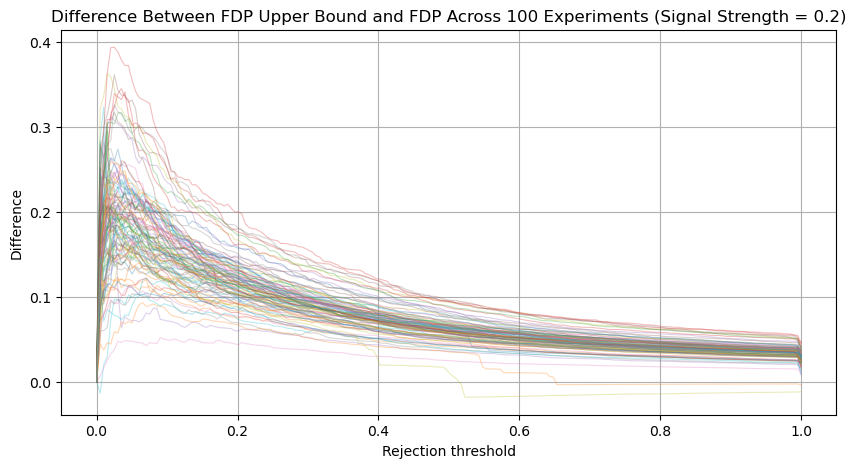

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

grid = np.linspace(0, 1, 200)
reps = 100

# Storage
fdp_list = []
fdp_upper_list = []
diff_list = []
valid_num = 0

plt.figure(figsize=(10, 5))

for rep in range(reps):
    fdp, fdp_upper = single_experiment(
        rep, signal_strength=0.2, boost_method=[True, True]
    )

    fdp_list.append(fdp)
    fdp_upper_list.append(fdp_upper)

    diff = fdp_upper - fdp
    diff_list.append(diff)

    valid_num += np.all(fdp_upper >= fdp)

    plt.plot(grid, diff, alpha=0.3, linewidth=0.8)

plt.xlabel('Rejection threshold')
plt.ylabel('Difference')
plt.title('Difference Between FDP Upper Bound and FDP Across 100 Experiments (Signal Strength = 0.2)')
plt.grid(True)

# Save figure

print('valid proportion', valid_num / reps)

# -----------------------
# SAVE ALL RESULTS HERE
# -----------------------

save_path = "experiment_result/FDP_multiple_runs_signal_0.2.npz"

np.savez(
    save_path,
    grid=grid,
    reps=reps,
    fdp_list=np.array(fdp_list),
    fdp_upper_list=np.array(fdp_upper_list),
    diff_list=np.array(diff_list),
    valid_num=valid_num,
)

print("Saved experiment results to:", save_path)


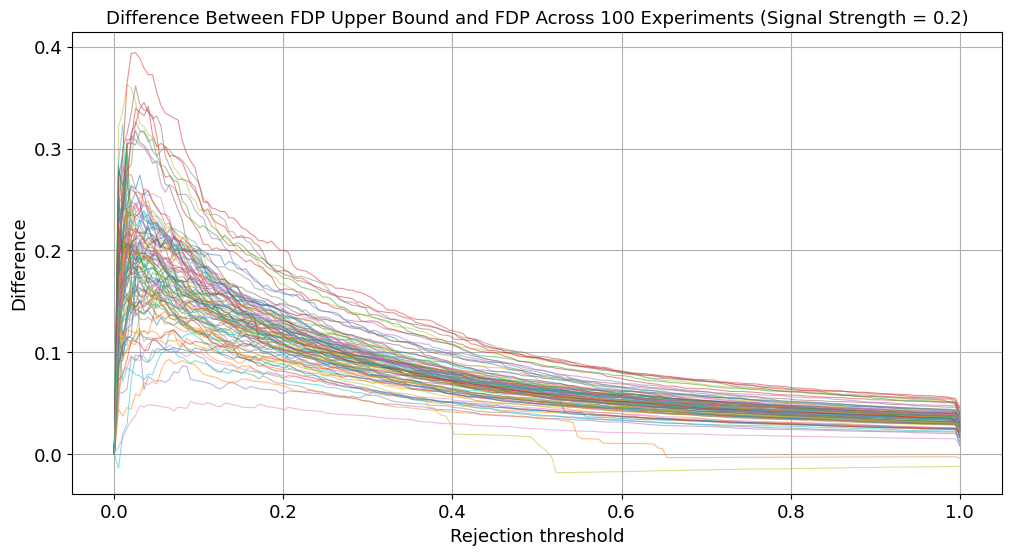

valid proportion (loaded): 0.97


In [14]:
# Load saved NPZ file
data = np.load(
    "experiment_result/FDP_multiple_runs_signal_0.2.npz",
    allow_pickle=True
)

grid = data["grid"]
fdp_list = data["fdp_list"]
fdp_upper_list = data["fdp_upper_list"]
diff_list = data["diff_list"]
reps = int(data["reps"])
valid_num = int(data["valid_num"])

# Replot
plt.figure(figsize=(12, 6))

for rep in range(reps):
    plt.plot(grid, diff_list[rep], alpha=0.5, linewidth=0.8)

plt.xlabel('Rejection threshold', fontsize = 13)
plt.ylabel('Difference', fontsize = 13)
plt.title('Difference Between FDP Upper Bound and FDP Across 100 Experiments (Signal Strength = 0.2)', fontsize = 13)
plt.grid(True)
plt.savefig('figure/outlier_multiple_0.2.pdf', format='pdf')
plt.show()

print('valid proportion (loaded):', valid_num / reps)

## Strength 0.5

upper bound on m 901
upper bound on m 906
upper bound on m 905
upper bound on m 911
upper bound on m 908
upper bound on m 909
upper bound on m 909
upper bound on m 908
upper bound on m 918
upper bound on m 911
upper bound on m 916
upper bound on m 908
upper bound on m 906
upper bound on m 905
upper bound on m 906
upper bound on m 908
upper bound on m 909
upper bound on m 915
upper bound on m 908
upper bound on m 897
upper bound on m 912
upper bound on m 908
upper bound on m 908
upper bound on m 908
upper bound on m 911
upper bound on m 913
upper bound on m 898
upper bound on m 904
upper bound on m 909
upper bound on m 906
upper bound on m 909
upper bound on m 909
upper bound on m 908
upper bound on m 912
upper bound on m 908
upper bound on m 907
upper bound on m 900
upper bound on m 902
upper bound on m 905
upper bound on m 913
upper bound on m 908
upper bound on m 896
upper bound on m 906
upper bound on m 907
upper bound on m 909
upper bound on m 909
upper bound on m 903
upper bound o

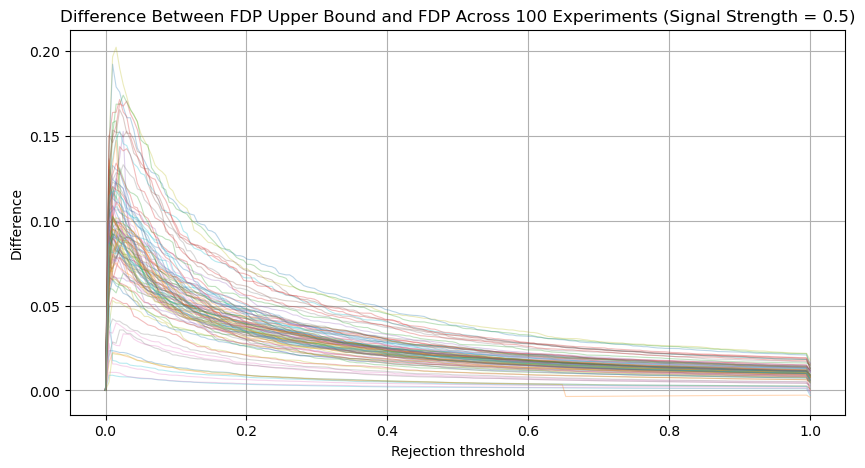

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

grid = np.linspace(0, 1, 200)
reps = 100

# Storage
fdp_list = []
fdp_upper_list = []
diff_list = []
valid_num = 0

plt.figure(figsize=(10, 5))

for rep in range(reps):
    fdp, fdp_upper = single_experiment(
        rep, signal_strength=0.5, boost_method=[True, True]
    )

    fdp_list.append(fdp)
    fdp_upper_list.append(fdp_upper)

    diff = fdp_upper - fdp
    diff_list.append(diff)

    valid_num += np.all(fdp_upper >= fdp)

    plt.plot(grid, diff, alpha=0.3, linewidth=0.8)

plt.xlabel('Rejection threshold')
plt.ylabel('Difference')
plt.title('Difference Between FDP Upper Bound and FDP Across 100 Experiments (Signal Strength = 0.5)')
plt.grid(True)

# Save figure

print('valid proportion', valid_num / reps)

# -----------------------
# SAVE ALL RESULTS HERE
# -----------------------

save_path = "experiment_result/FDP_multiple_runs_signal_0.5.npz"

np.savez(
    save_path,
    grid=grid,
    reps=reps,
    fdp_list=np.array(fdp_list),
    fdp_upper_list=np.array(fdp_upper_list),
    diff_list=np.array(diff_list),
    valid_num=valid_num,
)

print("Saved experiment results to:", save_path)


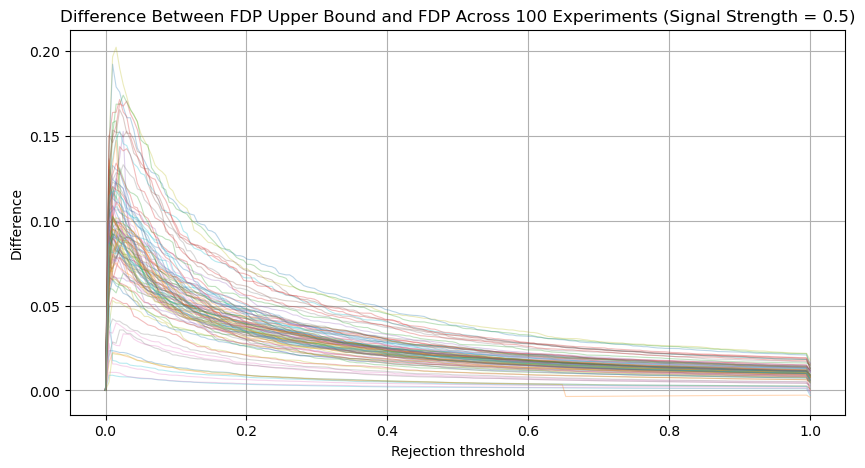

valid proportion (loaded): 0.95


In [38]:
# Load saved NPZ file
data = np.load(
    "experiment_result/FDP_multiple_runs_signal_0.5.npz",
    allow_pickle=True
)

grid = data["grid"]
fdp_list = data["fdp_list"]
fdp_upper_list = data["fdp_upper_list"]
diff_list = data["diff_list"]
reps = int(data["reps"])
valid_num = int(data["valid_num"])

# Replot
plt.figure(figsize=(10, 5))

for rep in range(reps):
    plt.plot(grid, diff_list[rep], alpha=0.3, linewidth=0.8)

plt.xlabel('Rejection threshold')
plt.ylabel('Difference')
plt.title('Difference Between FDP Upper Bound and FDP Across 100 Experiments (Signal Strength = 0.5)')
plt.grid(True)
plt.savefig('figure/outlier_multiple_0.5.pdf', format='pdf')
plt.show()

print('valid proportion (loaded):', valid_num / reps)

## Strength 1

upper bound on m 900
upper bound on m 903
upper bound on m 905
upper bound on m 906
upper bound on m 903
upper bound on m 907
upper bound on m 907
upper bound on m 905
upper bound on m 906
upper bound on m 907
upper bound on m 908
upper bound on m 907
upper bound on m 904
upper bound on m 903
upper bound on m 902
upper bound on m 906
upper bound on m 907
upper bound on m 906
upper bound on m 903
upper bound on m 896
upper bound on m 908
upper bound on m 905
upper bound on m 908
upper bound on m 905
upper bound on m 906
upper bound on m 907
upper bound on m 900
upper bound on m 900
upper bound on m 904
upper bound on m 905
upper bound on m 906
upper bound on m 906
upper bound on m 904
upper bound on m 905
upper bound on m 905
upper bound on m 905
upper bound on m 898
upper bound on m 900
upper bound on m 900
upper bound on m 907
upper bound on m 906
upper bound on m 899
upper bound on m 903
upper bound on m 903
upper bound on m 905
upper bound on m 908
upper bound on m 903
upper bound o

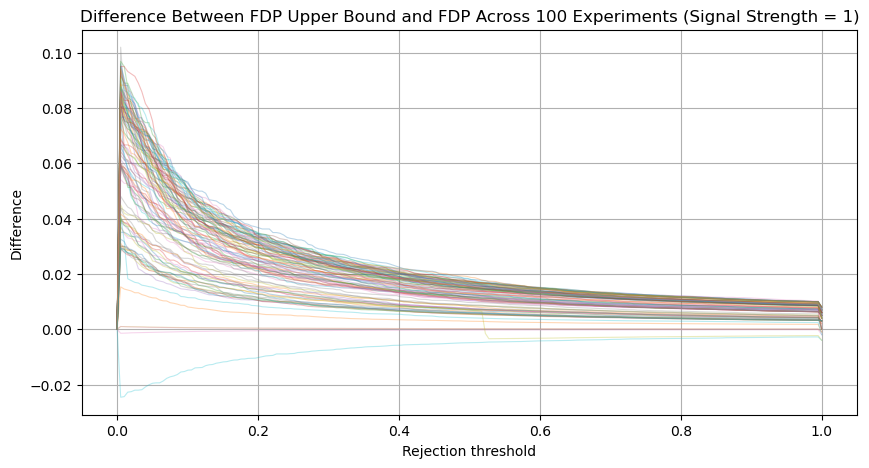

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

grid = np.linspace(0, 1, 200)
reps = 100

# Storage
fdp_list = []
fdp_upper_list = []
diff_list = []
valid_num = 0

plt.figure(figsize=(10, 5))

for rep in range(reps):
    fdp, fdp_upper = single_experiment(
        rep, signal_strength=1, boost_method=[True, True]
    )

    fdp_list.append(fdp)
    fdp_upper_list.append(fdp_upper)

    diff = fdp_upper - fdp
    diff_list.append(diff)

    valid_num += np.all(fdp_upper >= fdp)

    plt.plot(grid, diff, alpha=0.3, linewidth=0.8)

plt.xlabel('Rejection threshold')
plt.ylabel('Difference')
plt.title('Difference Between FDP Upper Bound and FDP Across 100 Experiments (Signal Strength = 1)')
plt.grid(True)

# Save figure

print('valid proportion', valid_num / reps)

# -----------------------
# SAVE ALL RESULTS HERE
# -----------------------

save_path = "experiment_result/FDP_multiple_runs_signal_1.npz"

np.savez(
    save_path,
    grid=grid,
    reps=reps,
    fdp_list=np.array(fdp_list),
    fdp_upper_list=np.array(fdp_upper_list),
    diff_list=np.array(diff_list),
    valid_num=valid_num,
)

print("Saved experiment results to:", save_path)


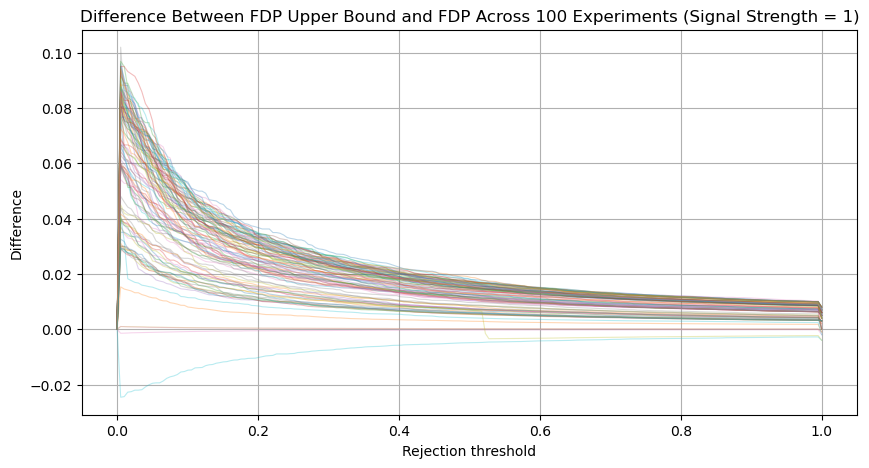

valid proportion (loaded): 0.93


In [40]:
# Load saved NPZ file
data = np.load(
    "experiment_result/FDP_multiple_runs_signal_1.npz",
    allow_pickle=True
)

grid = data["grid"]
fdp_list = data["fdp_list"]
fdp_upper_list = data["fdp_upper_list"]
diff_list = data["diff_list"]
reps = int(data["reps"])
valid_num = int(data["valid_num"])

# Replot
plt.figure(figsize=(10, 5))

for rep in range(reps):
    plt.plot(grid, diff_list[rep], alpha=0.3, linewidth=0.8)

plt.xlabel('Rejection threshold')
plt.ylabel('Difference')
plt.title('Difference Between FDP Upper Bound and FDP Across 100 Experiments (Signal Strength = 1)')
plt.grid(True)
plt.savefig('figure/outlier_multiple_0.5.pdf', format='pdf')
plt.show()

print('valid proportion (loaded):', valid_num / reps)

upper bound on m 1000


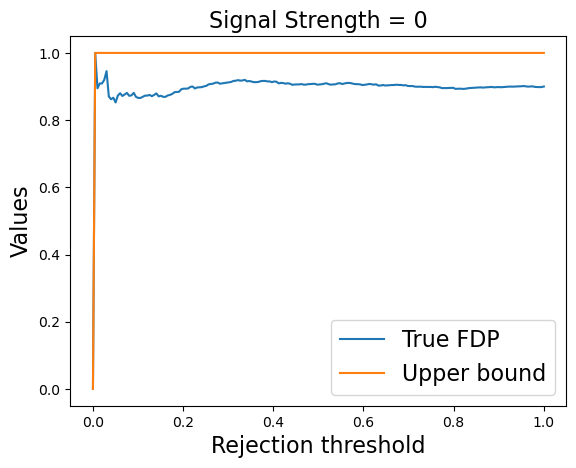

In [34]:
fdp, fdp_upper = single_experiment(1,signal_strength=0)
np.random.randint(1000, 2001)
plt.plot(grid, fdp, label='True FDP')
plt.plot(grid, fdp_upper, label='Upper bound')
plt.xlabel('Rejection threshold', fontsize=16)
plt.ylabel('Values', fontsize=16)
plt.title('Signal Strength = 0', fontsize=16)
plt.legend(fontsize=16)
plt.savefig(Path('outlier_pics')/'single_0.pdf', format = 'pdf')
plt.show()

upper bound on m 1000


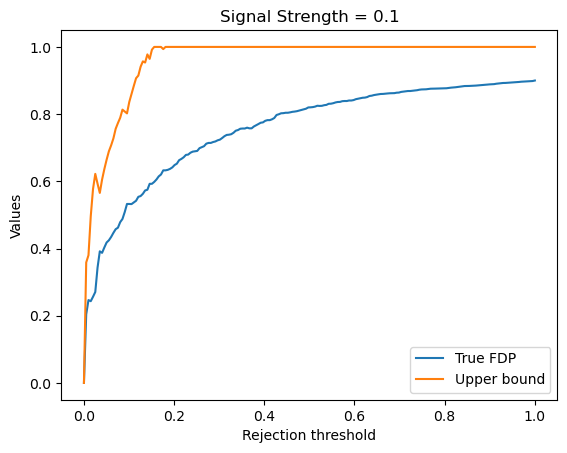

In [35]:
fdp, fdp_upper = single_experiment(1,signal_strength=0.1)
np.random.randint(1000, 2001)
plt.plot(grid, fdp, label='True FDP')
plt.plot(grid, fdp_upper, label='Upper bound')
plt.xlabel('Rejection threshold')
plt.ylabel('Values')
plt.title('Signal Strength = 0.1')
plt.legend()
plt.savefig(Path('outlier_pics')/'single_0.1.pdf', format = 'pdf')
plt.show()

upper bound on m 1000


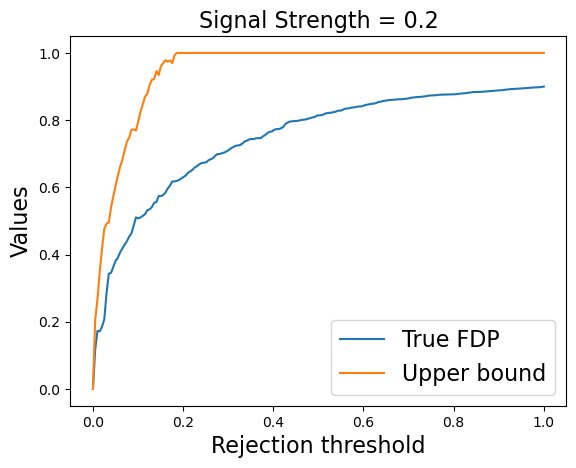

In [36]:
fdp, fdp_upper = single_experiment(1,signal_strength=0.2)
plt.plot(grid, fdp, label='True FDP')
plt.plot(grid, fdp_upper, label='Upper bound')
plt.xlabel('Rejection threshold', fontsize=16)
plt.ylabel('Values', fontsize=16)
plt.title('Signal Strength = 0.2', fontsize=16)
plt.legend(fontsize=16)
plt.savefig(Path('outlier_pics')/'single_0.2.pdf', format = 'pdf')
plt.show()

upper bound on m 1000


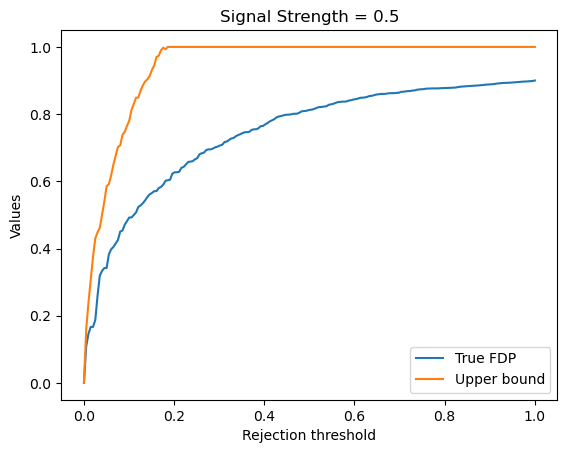

In [37]:
fdp, fdp_upper = single_experiment(1,signal_strength=0.5)
np.random.randint(1000, 2001)
plt.plot(grid, fdp, label='True FDP')
plt.plot(grid, fdp_upper, label='Upper bound')
plt.xlabel('Rejection threshold')
plt.ylabel('Values')
plt.title('Signal Strength = 0.5')
plt.legend()
plt.savefig(Path('outlier_pics')/'single_0.5.pdf', format = 'pdf')
plt.show()

upper bound on m 1000


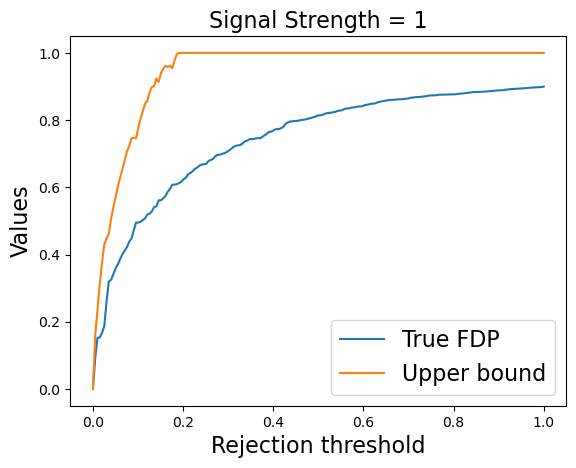

In [38]:
fdp, fdp_upper = single_experiment(1,signal_strength=1)
np.random.randint(1000, 2001)
plt.plot(grid, fdp, label='True FDP')
plt.plot(grid, fdp_upper, label='Upper bound')
plt.xlabel('Rejection threshold', fontsize=16)
plt.ylabel('Values', fontsize=16)
plt.title('Signal Strength = 1', fontsize=16)
plt.legend(fontsize=16)
plt.savefig(Path('outlier_pics')/'single_1.pdf', format = 'pdf')
plt.show()

In [39]:


# ### compute (true) FDP if reject all pval < alpha
# def FDP(alpha, pvals, truth):
#     R = sum(pvals <= alpha)
#     FR = R - sum(truth[pvals<=alpha])
#     return FR/np.maximum(R,1)
# T = len(alphas)
# FDP_true = np.zeros(T)
# FDP_marginal = np.zeros(T)
# FDP_simulation = np.zeros(T)
# for i in range(T):
#     FDP_true[i] = FDP(alphas[i], pvals, is_outlier)
#     FDP_marginal[i] = m * upper_marginal[i]/np.maximum(sum(pvals <= alphas[i]),1)
#     FDP_simulation[i] = m * upper_simulation[i]/np.maximum(sum(pvals <= alphas[i]),1)
# plt.plot(alphas, FDP_true, label='True FDP')
# plt.plot(alphas, purity*FDP_simulation, label='Simulation')
# plt.plot(alphas, purity*FDP_marginal, label='marginal', linestyle='--')
# plt.xlabel('alpha')
# plt.ylabel('Values')
# plt.legend()

# plt.xlim(0, 1)
# plt.ylim(0, 1)

# plt.show()

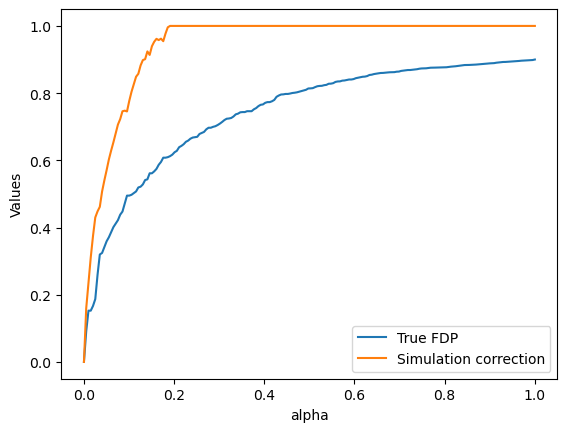

In [40]:
plt.plot(grid, fdp, label='True FDP')
plt.plot(grid, fdp_upper, label='Simulation correction')
plt.xlabel('alpha')
plt.ylabel('Values')
plt.legend()

# plt.xlim(0, 0.2)

plt.show()


## References

[1] Stephen Bates, Emmanuel Candes, Lihua Lei, Yaniv Romano, and Matteo Sesia. "Testing for Outliers with Conformal p-values". arXiv preprint (2021).